# Análisis exploratorio de datos de BTC

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [3]:
def obtener_datos_btc(fecha_inicio, fecha_fin):
    """Extrae datos de Yahoo Finance y calcula features básicas."""
    print(f"Descargando datos de BTC-USD desde {fecha_inicio}...")
    btc = yf.download("BTC-USD", start=fecha_inicio, end=fecha_fin)
    
    if isinstance(btc.columns, pd.MultiIndex):
        btc.columns = btc.columns.get_level_values(0)

    df = btc[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.dropna(inplace=True)
    
    # Feature básica: Retornos logarítmicos
    df['Retorno_Log'] = np.log(df['Close'] / df['Close'].shift(1))
    return df

def etiquetar_puntos_criticos(df, ventana):
    """
    Etiqueta máximos (1) y mínimos (-1) locales.
    Un punto es máximo/mínimo si es el extremo en +/- 'ventana' periodos.
    """
    # Creamos una copia para no alterar el original durante el cálculo
    temp_df = df.copy()
    
    # Buscamos el máximo y mínimo en la ventana centrada
    # center=True permite ver 'ventana' hacia atrás y 'ventana' hacia adelante
    temp_df['Max_Local'] = temp_df['High'].rolling(window=ventana*2+1, center=True).max()
    temp_df['Min_Local'] = temp_df['Low'].rolling(window=ventana*2+1, center=True).min()
    
    # Inicializamos la columna Target en 0 (Neutral)
    temp_df['Target'] = 0
    
    # Si el High actual es igual al Max_Local de la ventana, es un máximo (1)
    temp_df.loc[temp_df['High'] == temp_df['Max_Local'], 'Target'] = 1
    
    # Si el Low actual es igual al Min_Local de la ventana, es un mínimo (-1)
    temp_df.loc[temp_df['Low'] == temp_df['Min_Local'], 'Target'] = -1
    
    # Limpiamos columnas auxiliares
    temp_df.drop(columns=['Max_Local', 'Min_Local'], inplace=True)
    
    return temp_df


In [4]:
# --- EJECUCIÓN DEL PROYECTO APEX ---

# 1. Definimos parámetros
VENTANA_T = 3  # Esto buscará el máximo/mínimo en un rango de 7 velas (3 atrás, la actual, 3 adelante)

# 2. Obtenemos datos
df_apex = obtener_datos_btc(fecha_inicio="2024-01-01", fecha_fin="2026-01-01")

# 3. Aplicamos el etiquetado con la ventana parametrizada
df_apex = etiquetar_puntos_criticos(df_apex, ventana=VENTANA_T)

# 4. Resultados
print(f"\nEtiquetado completado con ventana t={VENTANA_T}")
print(df_apex['Target'].value_counts(dropna=False, normalize=True)) # Ver cuántos puntos encontramos
print("\nMuestra de puntos detectados (Target != 0):")
print(df_apex[df_apex['Target'] != 0].head(10))

Descargando datos de BTC-USD desde 2024-01-01...


[*********************100%***********************]  1 of 1 completed


Etiquetado completado con ventana t=3
Target
 0    0.820793
-1    0.093023
 1    0.086183
Name: proportion, dtype: float64

Muestra de puntos detectados (Target != 0):
Price               Open          High           Low         Close  \
Date                                                                 
2024-01-11  46656.074219  48969.371094  45678.644531  46368.585938   
2024-01-16  42499.335938  43566.273438  42085.996094  43154.945312   
2024-01-23  39518.714844  40127.351562  38521.894531  39845.550781   
2024-01-30  43300.226562  43838.945312  42711.371094  42952.609375   
2024-02-05  42577.621094  43494.250000  42264.816406  42658.667969   
2024-02-15  51836.785156  52820.066406  51371.628906  51938.554688   
2024-02-20  51777.726562  52945.050781  50792.312500  52284.875000   
2024-02-23  51283.906250  51497.933594  50561.777344  50731.949219   
2024-02-28  57071.097656  63913.132812  56738.425781  62504.789062   
2024-03-05  68341.054688  69170.625000  59323.910156  63801.1

In [5]:
def graficar_etiquetas(df, titulo="Proyecto Apex: Detección de Máximos y Mínimos"):
    plt.figure(figsize=(15, 8))
    
    # 1. Graficamos el precio de cierre como referencia
    plt.plot(df.index, df['Close'], label='Precio de Cierre', color='black', alpha=0.3, lw=1)
    
    # 2. Resaltamos los Máximos (Target == 1) usando el High
    maximos = df[df['Target'] == 1]
    plt.scatter(maximos.index, maximos['High'], color='red', label='Máximo Local', marker='v', s=100)
    
    # 3. Resaltamos los Mínimos (Target == -1) usando el Low
    minimos = df[df['Target'] == -1]
    plt.scatter(minimos.index, minimos['Low'], color='green', label='Mínimo Local', marker='^', s=100)

    # 4. Agregamos la media móvil de 28 periodos para contexto
    df['MA28'] = df['Close'].rolling(window=28).mean()
    plt.plot(df.index, df['MA28'], label='MA 28', color='blue', alpha=0.7, lw=1)
    
    # 5. Agregamos la media móvil de 7 periodos para contexto
    df['MA7'] = df['Close'].rolling(window=7).mean()
    plt.plot(df.index, df['MA7'], label='MA 7', color='orange', alpha=0.7, lw=1)

    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel('Precio BTC (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


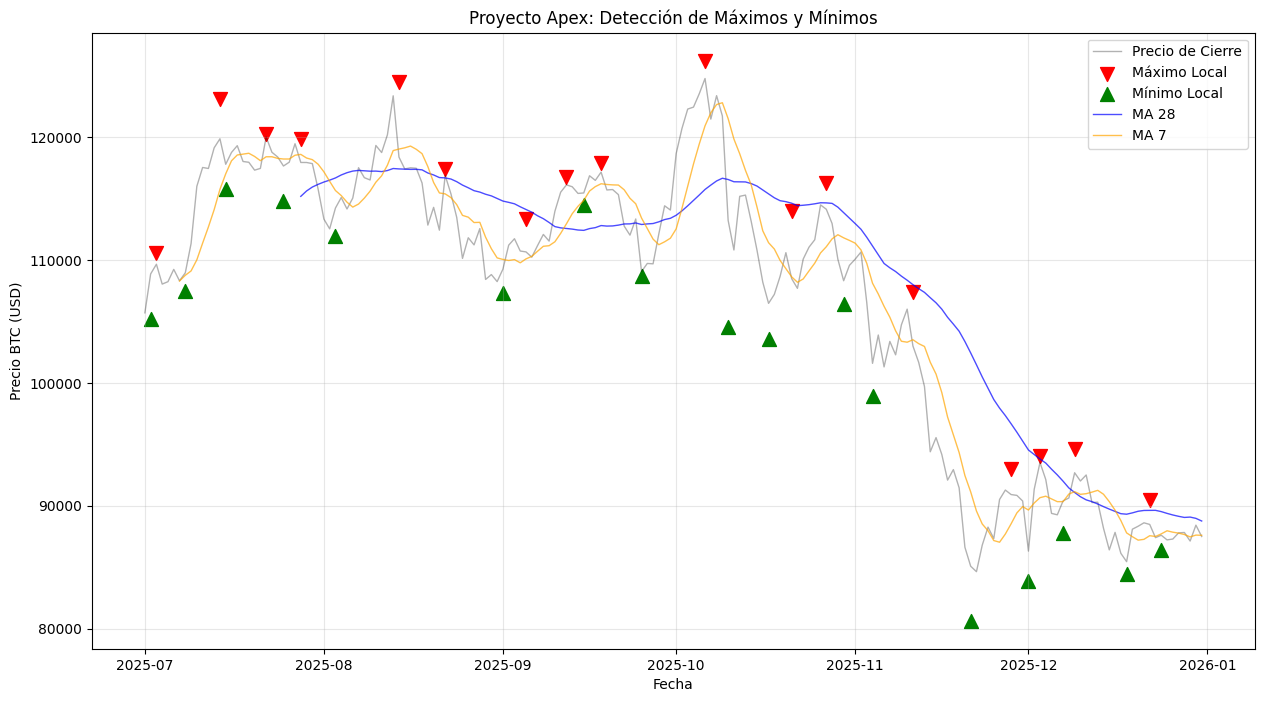

In [6]:
# --- USO ---
# Suponiendo que df_apex ya tiene la columna 'Target'
# Filtramos un periodo pequeño para que la gráfica no se vea saturada (ej. últimos 6 meses)
df_reciente = df_apex.last('6M') 
graficar_etiquetas(df_reciente)

In [7]:
# Determinar el número de días entre puntos de inflexión (Target != 0)
puntos_inflexion = df_apex[df_apex['Target'] != 0]
puntos_inflexion['Dias_Entre'] = puntos_inflexion.index.to_series().diff().dt.days
print("\nDías entre puntos de inflexión:")
print(puntos_inflexion['Dias_Entre'].describe())


Días entre puntos de inflexión:
count    130.000000
mean       5.484615
std        2.782098
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       17.000000
Name: Dias_Entre, dtype: float64


Ejercicio para tener una idea de cuánto es el rendimiento generado frente a una estrategia de compra dado un punto mínimo y, una venta en un punto máximo, suponiendo que las órdenes se ejecutan en el punto _High_ o _Low_.

In [8]:
puntos_inflexion.head(10)

Price,Open,High,Low,Close,Volume,Retorno_Log,Target,Dias_Entre
Date,,,,,,,,
2024-01-11,46656.074219,48969.371094,45678.644531,46368.585938,45833734549,-0.005574,1,NaN
2024-01-16,42499.335938,43566.273438,42085.996094,43154.945312,24062872740,0.015011,1,5.0
2024-01-23,39518.714844,40127.351562,38521.894531,39845.550781,29244553045,0.008524,-1,7.0
2024-01-30,43300.226562,43838.945312,42711.371094,42952.609375,23842814518,-0.007784,1,7.0
2024-02-05,42577.621094,43494.250000,42264.816406,42658.667969,18715487317,0.001762,-1,6.0
2024-02-15,51836.785156,52820.066406,51371.628906,51938.554688,38564360533,0.002156,1,10.0
2024-02-20,51777.726562,52945.050781,50792.312500,52284.875000,33353758256,0.009720,1,5.0
2024-02-23,51283.906250,51497.933594,50561.777344,50731.949219,21427078270,-0.011232,-1,3.0
2024-02-28,57071.097656,63913.132812,56738.425781,62504.789062,83239156760,0.090695,1,5.0


In [10]:
puntos_inflexion['delayed_target'] = puntos_inflexion['Target'].shift(-1)

condiciones = [
    (puntos_inflexion['delayed_target'] == 1) 
    & (puntos_inflexion['Target'] == -1),

    (puntos_inflexion['delayed_target'] == -1) 
    & (puntos_inflexion['Target'] == 1)
]

estrategias = ['Compra', 'Venta']
puntos_inflexion['Estrategia'] = np.select(
    condiciones, 
    estrategias, 
    default='Hodl')

In [11]:
print("\nPuntos de inflexión con estrategia sugerida:")
print(puntos_inflexion[['Estrategia','Close','High','Low']].head(10))


Puntos de inflexión con estrategia sugerida:
Price      Estrategia         Close          High           Low
Date                                                           
2024-01-11       Hodl  46368.585938  48969.371094  45678.644531
2024-01-16      Venta  43154.945312  43566.273438  42085.996094
2024-01-23     Compra  39845.550781  40127.351562  38521.894531
2024-01-30      Venta  42952.609375  43838.945312  42711.371094
2024-02-05     Compra  42658.667969  43494.250000  42264.816406
2024-02-15       Hodl  51938.554688  52820.066406  51371.628906
2024-02-20      Venta  52284.875000  52945.050781  50792.312500
2024-02-23     Compra  50731.949219  51497.933594  50561.777344
2024-02-28      Venta  62504.789062  63913.132812  56738.425781
2024-03-05     Compra  63801.199219  69170.625000  59323.910156


In [31]:
# Quitando las estrategias Hold, valido que las estrategias de compra y venta se alternen correctamente
validacion = puntos_inflexion[puntos_inflexion['Estrategia'] != 'Hodl']['Estrategia']
validacion.loc[validacion.shift(1) == validacion] # Esto debería devolver una Serie vacía si no hay errores en la alternancia

Series([], Name: Estrategia, dtype: object)

In [33]:
# Analisis del rendimiento generado entre compras y ventas
rendimientos = puntos_inflexion[
    puntos_inflexion['Estrategia'] != 'Hodl'][
        ['High','Low','Close','Estrategia','Dias_Entre']
        ]  # Nos quedamos solo con los puntos de compra/venta

# Ahora se crea la columna price_strategy de modo que si es compra se toma el precio de compra (Low) y si es venta se toma el precio de venta (High)
rendimientos['Price_Strategy'] = np.where(
    rendimientos['Estrategia'] == 'Compra',
    rendimientos['Low'],
    rendimientos['High']
)

# Elimino el primer registro si es una venta (ya que no tenemos un precio de compra previo para calcular el rendimiento)
if rendimientos.iloc[0]['Estrategia'] == 'Venta':
    rendimientos = rendimientos.iloc[1:]

# Recalculo los dias entre
rendimientos['Dias_Entre'] = rendimientos.index.to_series().diff().dt.days

# Si la estrategia es venta, se calcula el rendimiento, sino es cero
rendimientos["rate_return"] = np.where(
    rendimientos['Estrategia'] == 'Venta',
    rendimientos['Price_Strategy'] / rendimientos['Price_Strategy'].shift(1) - 1,
    0
)

# Como escenario base, asumo inversion inicial de 1000 USD y calculo el valor acumulado de la inversioon a lo largo del tiempo
rendimientos['Valor_Acumulado'] = (1 + rendimientos['rate_return']).cumprod() * 1000

# Mostramos los resultados de los rendimientos
# Total de dias de inversion, rendimiento total, rendimiento anualizado, etc.
total_dias = rendimientos['Dias_Entre'].sum()
ganancia_total = rendimientos['Valor_Acumulado'].iloc[-1] - 1000
rendimiento_total = rendimientos['Valor_Acumulado'].iloc[-1] / 1000 - 1
rendimiento_anualizado = (1 + rendimiento_total) ** (365 / total_dias) - 1

print(f"\nTotal de días de inversión: {total_dias}. Fecha inicial: {rendimientos.index[0].date()}, Fecha final: {rendimientos.index[-1].date()}")
print(f"Rendimiento total en monto: {ganancia_total:.2f} USD")
print(f"\nRendimiento Total: {rendimiento_total:.2%}")
print(f"Rendimiento Anualizado: {rendimiento_anualizado:.2%}")



Total de días de inversión: 699.0. Fecha inicial: 2024-01-23, Fecha final: 2025-12-22
Rendimiento total en monto: 361735.88 USD

Rendimiento Total: 36173.59%
Rendimiento Anualizado: 2070.47%


Esos resultados son utópicos ya que es considerando que efectivamente se logró la estrategia en los puntos mínimos y máximos sin fallar, y sin considerar fees.

En la práctica, hay fees por transacción así como las estrategias de compra y venta son poco probables realizarlas en los puntos mínimos o máximos locales.

Ahora bien, repito el ejercicio pero considerando las estrategias con los precios de cierre, dado que mi información la obtengo de manera diaria, lo más lógico es considerar dicho precio.

In [34]:
# Analisis del rendimiento generado entre compras y ventas
rendimientos_c = puntos_inflexion[
    puntos_inflexion['Estrategia'] != 'Hodl'][
        ['High','Low','Close','Estrategia','Dias_Entre']
        ]  # Nos quedamos solo con los puntos de compra/venta

# Elimino el primer registro si es una venta (ya que no tenemos un precio de compra previo para calcular el rendimiento)
if rendimientos_c.iloc[0]['Estrategia'] == 'Venta':
    rendimientos_c = rendimientos_c.iloc[1:]

# Recalculo los dias entre
rendimientos_c['Dias_Entre'] = rendimientos_c.index.to_series().diff().dt.days

# Si la estrategia es venta, se calcula el rendimiento, sino es cero
rendimientos_c["rate_return"] = np.where(
    rendimientos_c['Estrategia'] == 'Venta',
    rendimientos_c['Close'] / rendimientos_c['Close'].shift(1) - 1,
    0
)

# Como escenario base, asumo inversion inicial de 1000 USD y calculo el valor acumulado de la inversioon a lo largo del tiempo
rendimientos_c['Valor_Acumulado'] = (1 + rendimientos_c['rate_return']).cumprod() * 1000

# Mostramos los resultados de los rendimientos
# Total de dias de inversion, rendimiento total, rendimiento anualizado, etc.
total_dias = rendimientos_c['Dias_Entre'].sum()
ganancia_total_c = rendimientos_c['Valor_Acumulado'].iloc[-1] - 1000
rendimiento_total_c = rendimientos_c['Valor_Acumulado'].iloc[-1] / 1000 - 1
rendimiento_anualizado_c = (1 + rendimiento_total_c) ** (365 / total_dias) - 1

print(f"\nTotal de días de inversión: {total_dias}. Fecha inicial: {rendimientos_c.index[0].date()}, Fecha final: {rendimientos_c.index[-1].date()}")
print(f"Rendimiento total en monto: {ganancia_total_c:.2f} USD")
print(f"\nRendimiento Total: {rendimiento_total_c:.2%}")
print(f"Rendimiento Anualizado: {rendimiento_anualizado_c:.2%}")



Total de días de inversión: 699.0. Fecha inicial: 2024-01-23, Fecha final: 2025-12-22
Rendimiento total en monto: 25551.55 USD

Rendimiento Total: 2555.16%
Rendimiento Anualizado: 454.15%


Por último, considerando los precios de compra Open suponiendo que las estrategias se ejecutan amaneciendo, por tanto, la información más reciendo serían al día de ayer.

In [36]:
# Analisis del rendimiento generado entre compras y ventas
rendimientos_o = puntos_inflexion[
    puntos_inflexion['Estrategia'] != 'Hodl'][
        ['High','Low','Open','Estrategia','Dias_Entre']
        ]  # Nos quedamos solo con los puntos de compra/venta

# Elimino el primer registro si es una venta (ya que no tenemos un precio de compra previo para calcular el rendimiento)
if rendimientos_o.iloc[0]['Estrategia'] == 'Venta':
    rendimientos_o = rendimientos_o.iloc[1:]

# Recalculo los dias entre
rendimientos_o['Dias_Entre'] = rendimientos_o.index.to_series().diff().dt.days

# Si la estrategia es venta, se calcula el rendimiento, sino es cero
rendimientos_o["rate_return"] = np.where(
    rendimientos_o['Estrategia'] == 'Venta',
    rendimientos_o['Open'] / rendimientos_o['Open'].shift(1) - 1,
    0
)

# Como escenario base, asumo inversion inicial de 1000 USD y calculo el valor acumulado de la inversioon a lo largo del tiempo
rendimientos_o['Valor_Acumulado'] = (1 + rendimientos_o['rate_return']).cumprod() * 1000

# Mostramos los resultados de los rendimientos
# Total de dias de inversion, rendimiento total, rendimiento anualizado, etc.
total_dias = rendimientos_o['Dias_Entre'].sum()
ganancia_total_o = rendimientos_o['Valor_Acumulado'].iloc[-1] - 1000
rendimiento_total_o = rendimientos_o['Valor_Acumulado'].iloc[-1] / 1000 - 1
rendimiento_anualizado_o = (1 + rendimiento_total_o) ** (365 / total_dias) - 1

print(f"\nTotal de días de inversión: {total_dias}. Fecha inicial: {rendimientos_o.index[0].date()}, Fecha final: {rendimientos_o.index[-1].date()}")
print(f"Rendimiento total en monto: {ganancia_total_o:.2f} USD")
print(f"\nRendimiento Total: {rendimiento_total_o:.2%}")
print(f"Rendimiento Anualizado: {rendimiento_anualizado_o:.2%}")



Total de días de inversión: 699.0. Fecha inicial: 2024-01-23, Fecha final: 2025-12-22
Rendimiento total en monto: 13475.94 USD

Rendimiento Total: 1347.59%
Rendimiento Anualizado: 303.70%


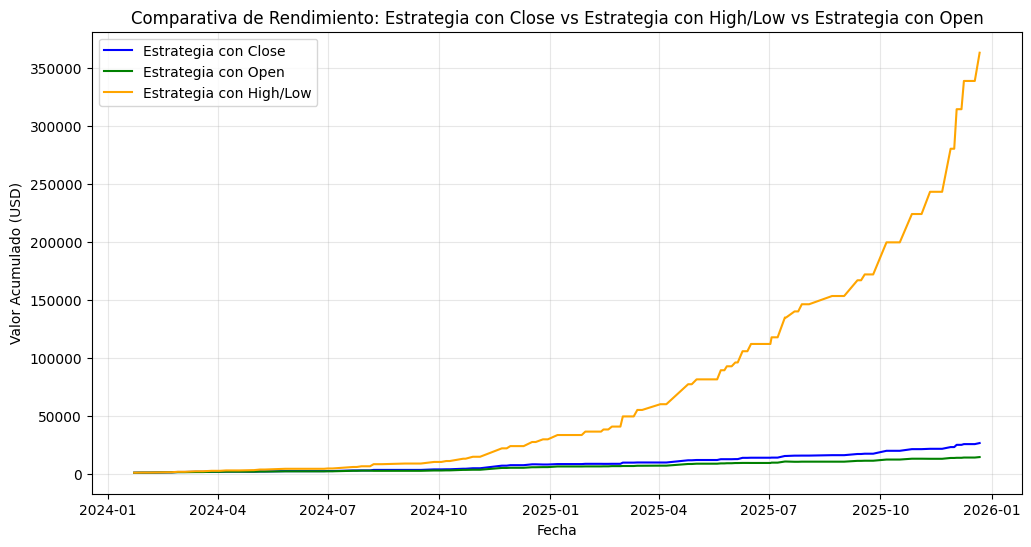

In [37]:
# Comparativa del rendimiento con precios High, Close y Open
plt.figure(figsize=(12, 6))
plt.plot(rendimientos_c.index, rendimientos_c['Valor_Acumulado'], label='Estrategia con Close', color='blue')
plt.plot(rendimientos_o.index, rendimientos_o['Valor_Acumulado'], label='Estrategia con Open', color='green')
plt.plot(rendimientos.index, rendimientos['Valor_Acumulado'], label='Estrategia con High/Low', color='orange')
plt.title('Comparativa de Rendimiento: Estrategia con Close vs Estrategia con High/Low vs Estrategia con Open')
plt.xlabel('Fecha')
plt.ylabel('Valor Acumulado (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En conclusión, en el trading profesional, se suele estimar los puntos máximos y mínimos locales con los precios _High_ y _Low_ en _n_ días para marcar bien un techo físico al comparar con los precios _Highs_ anteriores (y análogamente con los precios _Lows_). Ahora bien, si las estrategias se pueden ejecutar al momento que se detecta un punto máximo o mínimo, definitivamente el rendimiento supera a si consideramos un precio de cierre o de apertura, y esto se debe a la "trampa de los cierres", pues pudo haber alcanzado un precio mucho mayor horas antes.

## Indicadores

In [ ]:
# Función para agregar indicadores técnicos básicos al dataset

def agregar_indicadores(
        df: pd.DataFrame,
        rsi_periodo: int = 14,
        bollinger_periodo: int = 20,
        volumen_periodo: int = 20
    ) -> pd.DataFrame:
    """
    Calcula indicadores técnicos básicos para usar como features.ç

    - RSI (Relative Strength Index): Mide la fuerza de las tendencias.
    - Bandas de Bollinger: Miden la volatilidad y posibles puntos de reversión.
    - Retornos y Volumen Relativo: Miden la dinámica del precio y el interés del mercado.

    Params:
    - df: DataFrame con columnas 'Open', 'High', 'Low', 'Close', 'Volume'.
    - rsi_periodo: Número de periodos para calcular el RSI (default=14).
    - bollinger_periodo: Número de periodos para calcular las Bandas de Bollinger (default=20).
    - volumen_periodo: Número de periodos para calcular el Volumen Relativo (default=20).   

    Returns:
    - DataFrame con nuevas columnas de indicadores técnicos.
    
    """
    temp_df = df.copy()
    
    # 1. RSI (Relative Strength Index) - 14 periodos
    delta = temp_df['Close'].diff()
    ganancia = delta.where(delta > 0, 0)
    perdida = -delta.where(delta < 0, 0)
    media_ganancia = ganancia.rolling(window=rsi_periodo).mean()
    media_perdida = perdida.rolling(window=rsi_periodo).mean()
    rs = media_ganancia / media_perdida
    temp_df['RSI_' + str(rsi_periodo)] = 100 - (100 / (1 + rs))
    
    # 2. Bandas de Bollinger (Volatilidad) - 20 periodos
    temp_df['SMA_' + str(bollinger_periodo)] = temp_df['Close'].rolling(window=bollinger_periodo).mean()
    std_20 = temp_df['Close'].rolling(window=bollinger_periodo).std()
    temp_df['BB_Upper'] = temp_df['SMA_' + str(bollinger_periodo)] + (std_20 * 2)
    temp_df['BB_Lower'] = temp_df['SMA_' + str(bollinger_periodo)] - (std_20 * 2)
    
    # Distancia del precio a las bandas (muy útil para el modelo)
    temp_df['Dist_BB_Upper'] = (temp_df['High'] - temp_df['BB_Upper']) / temp_df['BB_Upper']
    temp_df['Dist_BB_Lower'] = (temp_df['Low'] - temp_df['BB_Lower']) / temp_df['BB_Lower']
    
    # 3. Retornos y Volumen
    temp_df['Retorno_1d'] = temp_df['Close'].pct_change()
    temp_df['Volumen_Relativo'] = temp_df['Volume'] / temp_df['Volume'].rolling(window=volumen_periodo).mean()
    
    # Eliminamos las filas iniciales que quedaron con NaN (nulos) por los cálculos
    temp_df.dropna(inplace=True)
    
    return temp_df

In [ ]:
# Aplicamos la función a nuestro dataset
# (Asumiendo que 'df_apex' ya tiene la columna 'Target' del paso anterior)
df_apex = agregar_indicadores(df_apex)
print("Features agregadas con éxito. Tamaño del dataset:", df_apex.shape)